# Case 4: Churn Detective — Telecom Retention Analysis

**Brief:** A mid-sized telecom is bleeding postpaid customers (2.3% monthly churn vs 1.5% industry benchmark). The CMO wants to know *who* is about to leave and *why* before signing off on a retention campaign budget.

**Notebook structure:**

0. Assumptions
1. EDA
2. Preprocessing
3. Modeling
4. SHAP Interpretability
5. Churner Segmentation
6. Retention Recommendations
7. Limitations & Risks
8. 60-Day Success Metrics

## 0. Assumptions

Before touching the data, here are the assumptions driving every decision in this notebook:

1. The dataset is treated as real telecom data even though it's synthetic, all recommendations are made as if these are actual customers.
2. `churned = 1` means the customer left within the observation month (30-day window). The brief doesn't define this explicitly so I picked the most common industry definition.
3. All customers are postpaid. The brief explicitly scopes to postpaid churn so no prepaid modeling.
4. Retention offer cost ≈ $100 USD, LTV saved per retained customer ≈ $670 USD. Grounded in the dataset: mean monthly charges = $69.84 × 24 months × 40% margin = $670. Offer cost = ~1 month bill credit, standard US telecom practice. The CMO's finance team should validate before acting.
5. Customer behavior next quarter will follow similar patterns to the historical data. Without this stationarity assumption the model's predictions aren't actionable.
6. The CMO's primary success metric is churn rate reduction in the targeted cohort vs. a holdout control and not offer redemption rate.

In [1]:
# --- Imports ---
# Standard data manipulation and visualisation libraries
import pandas as pd # core lib to work with datas
import numpy as np # for num operations
import matplotlib.pyplot as plt # for charts
import matplotlib.ticker as mticker  # used to format y-axis as percentages
import seaborn as sns # stat oriented plots
import plotly.express as px           # for interactive charts
import warnings
import os

warnings.filterwarnings('ignore')     # please silently supresses all wraning messages so they dont clutter the notebook output
sns.set_theme(style='whitegrid', palette='muted') # whitegrid adds light horizontal gridlines for readibility, muted uses softer proffesional colours across all plots
plt.rcParams['figure.dpi'] = 120      # sharper figures when saved for the deck

# Create output folder if it doesn't exist yet
os.makedirs('../outputs/figures', exist_ok=True)

# Load the dataset — path is relative to the notebooks/ folder
df = pd.read_csv('../data/case4_telecom_churn.csv')
print(f'Shape: {df.shape}')           # (7000, 21) will be there! 
df.head()

Shape: (7000, 21)


,customer_id,tenure_months,contract_type,monthly_charges,total_charges,internet_service,online_security,tech_support,streaming_tv,payment_method,...,senior_citizen,partner,dependents,phone_service,multiple_lines,support_calls_3mo,avg_data_gb_3mo,late_payments_6mo,plan_changes_6mo,churned
0,CUST50000,8,Month-to-month,44.30,309.51,DSL,No,No,No,Electronic check,...,0,No,Yes,Yes,No,1,30.45,0,0,1
1,CUST50001,24,Month-to-month,100.38,2196.66,Fiber optic,No,Yes,No,Electronic check,...,0,Yes,No,Yes,Yes,3,57.32,0,1,1
2,CUST50002,10,Month-to-month,106.34,974.70,DSL,Yes,No,Yes,Bank transfer (auto),...,0,No,Yes,Yes,No,0,6.47,0,0,1
3,CUST50003,72,Month-to-month,64.87,4283.95,No,No internet service,No internet service,No internet service,Credit card (auto),...,0,No,No,Yes,No,1,0.00,0,0,1
4,CUST50004,42,Month-to-month,110.74,3971.34,DSL,Yes,Yes,Yes,Electronic check,...,0,Yes,No,Yes,No,1,26.51,0,1,0


## 1. EDA

##### Exploratory Data Analysis

In [2]:
# Check data types and missing values before any modeling
# We need to know which columns are categorical (object) vs numeric
# and whether there's any missing data that needs handling
print('--- dtypes ---')
print(df.dtypes) # checking the data type of every column, object, float64, int64,bool? (by the way 34 refers to how many bits of computer memory are used to store each number)
print('\n--- null counts ---')
print(df.isnull().sum()) # will help tell the missing values, as missing values will break most ML models! So need to sanitize first! 

--- dtypes ---
customer_id              str
tenure_months          int64
contract_type            str
monthly_charges      float64
total_charges        float64
internet_service         str
online_security          str
tech_support             str
streaming_tv             str
payment_method           str
paperless_billing        str
senior_citizen         int64
partner                  str
dependents               str
phone_service            str
multiple_lines           str
support_calls_3mo      int64
avg_data_gb_3mo      float64
late_payments_6mo      int64
plan_changes_6mo       int64
churned                int64
dtype: object

--- null counts ---
customer_id          0
tenure_months        0
contract_type        0
monthly_charges      0
total_charges        0
internet_service     0
online_security      0
tech_support         0
streaming_tv         0
payment_method       0
paperless_billing    0
senior_citizen       0
partner              0
dependents           0
phone_service      

Overall churn rate: 36.2%
Churned: 2,531  |  Retained: 4,469


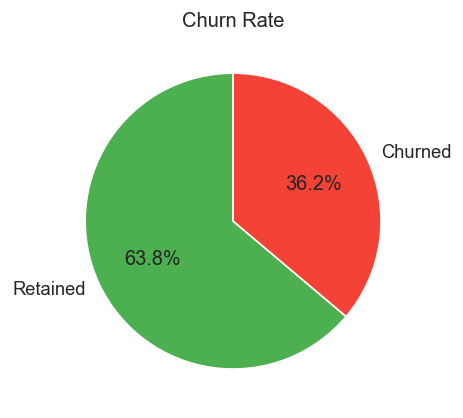

In [ ]:
# Overall churn rate — this is our baseline number
# Everything downstream is measured against this
churn_rate = df['churned'].mean() # fraction of 1s
print(f'Overall churn rate: {churn_rate:.1%}')   # .1-> one decimal place, % will multi by 100
print(f'Churned: {df["churned"].sum():,}  |  Retained: {(df["churned"]==0).sum():,}') # :, adds comma seperators to large numbers

# Pie chart
fig, ax = plt.subplots(figsize=(4, 4)) # fig is the entire figure, ax is the axes; where the drawing happens
df['churned'].value_counts().plot.pie( # value_counts how many 0s and 1s exist
    labels=['Retained', 'Churned'], autopct='%1.1f%%', # autopct, prints percentage inside each slice
    colors=['#4CAF50', '#F44336'], ax=ax, startangle=90 # green for retained and red for churned, startangle=90, rotates chart so it strat from the top
)

ax.set_title('Churn Rate')
plt.tight_layout() # auto adjusts spacing so nothing gets cut off
plt.savefig('../outputs/figures/churn_rate_pie.png')  # will require in deck
plt.show()

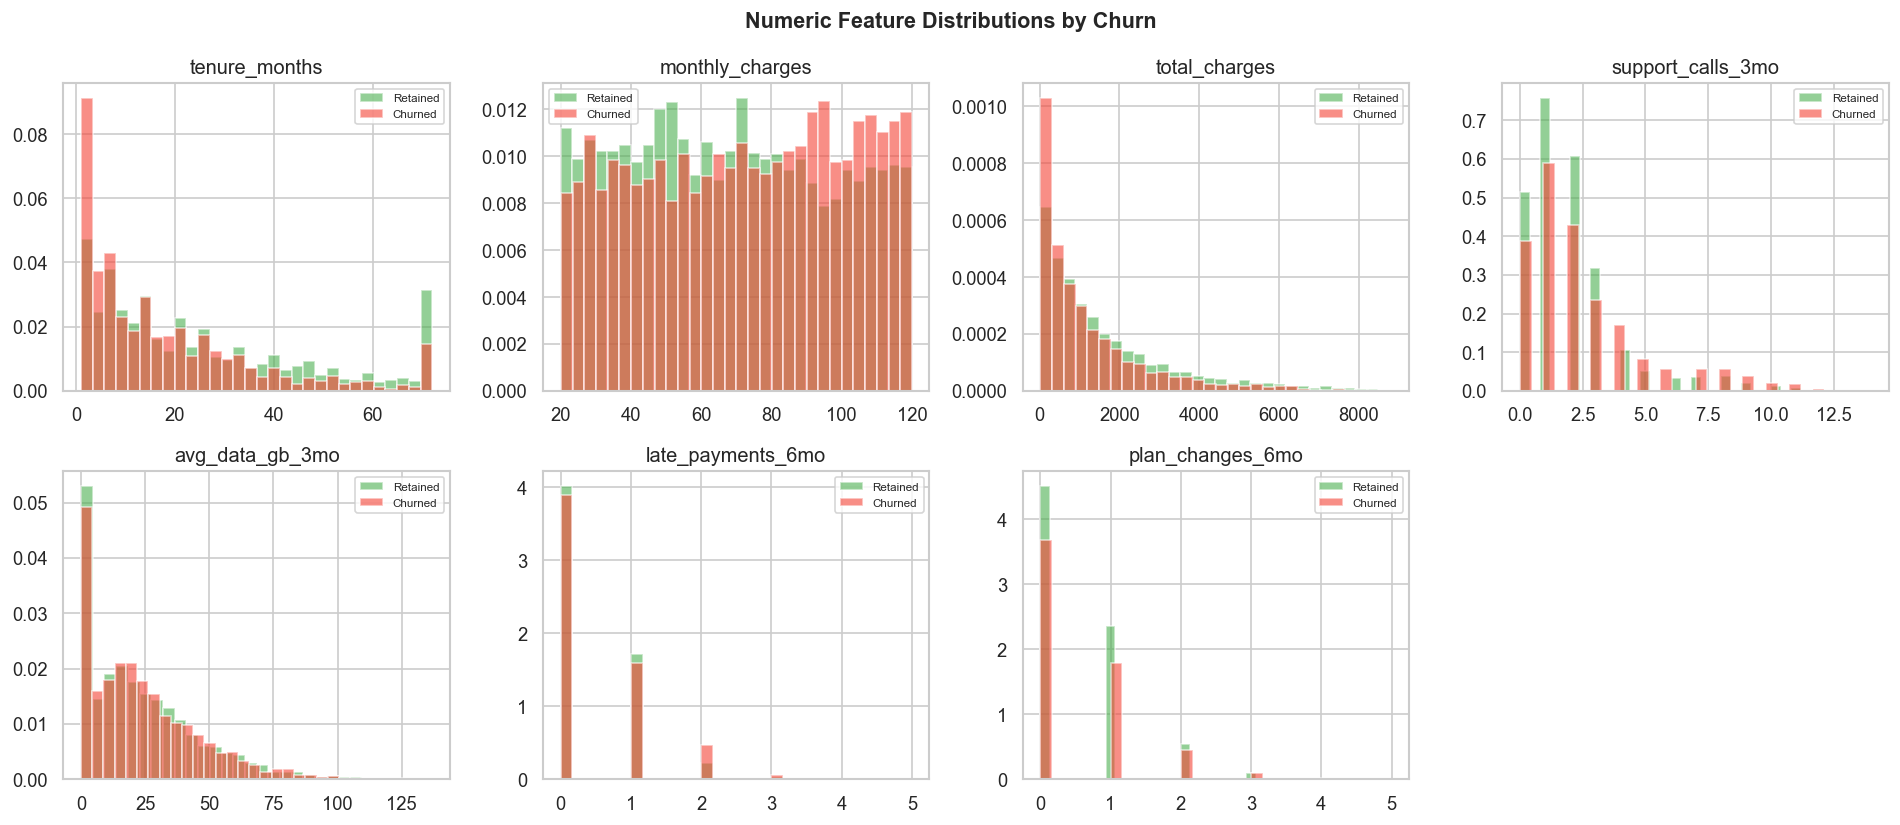

In [ ]:
# Distribution of numeric features split by churn status
# Looking for features where churners and retained customers look clearly different
# Those are likely strong predictors

# these are the numeric columns!
num_cols = ['tenure_months', 'monthly_charges', 'total_charges',
            'support_calls_3mo', 'avg_data_gb_3mo', 'late_payments_6mo', 'plan_changes_6mo']

fig, axes = plt.subplots(2, 4, figsize=(16, 7)) # 2x4
axes = axes.flatten() # flatten will return in in 1D (2x4) will be (1x8)
for i, col in enumerate(num_cols): # enumerate will give index number and cloumn name at same time
    for label, color in [(0, '#4CAF50'), (1, '#F44336')]:
        # density=True normalises both groups so they're comparable
        # even though retained customers outnumber churners
        # histogram
        axes[i].hist(df[df['churned'] == label][col], # first filtering rows either churned or retained only, then picks the current columns
                     bins=30, # data into 30 bars, 30 as commony used as default choice
                     alpha=0.6, # 60% transparent so overlapping bars are visible
                     color=color, # earlier colurs only green and red
                     label='Retained' if label == 0 else 'Churned', 
                     density=True) # for normalising the histogram, retained bars will be taller
                     # orientation='horizontal')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
axes[-1].set_visible(False)  # hide the empty 8th subplot, as we are using 7 columns only, as we flattened to 1D it will be 8, so just make is invisible
plt.suptitle('Numeric Feature Distributions by Churn', fontsize=13, fontweight='bold') # sub is a master title above all the 8 subplots
plt.tight_layout() # autofixes spacing
plt.savefig('../outputs/figures/numeric_distributions.png')
plt.show()

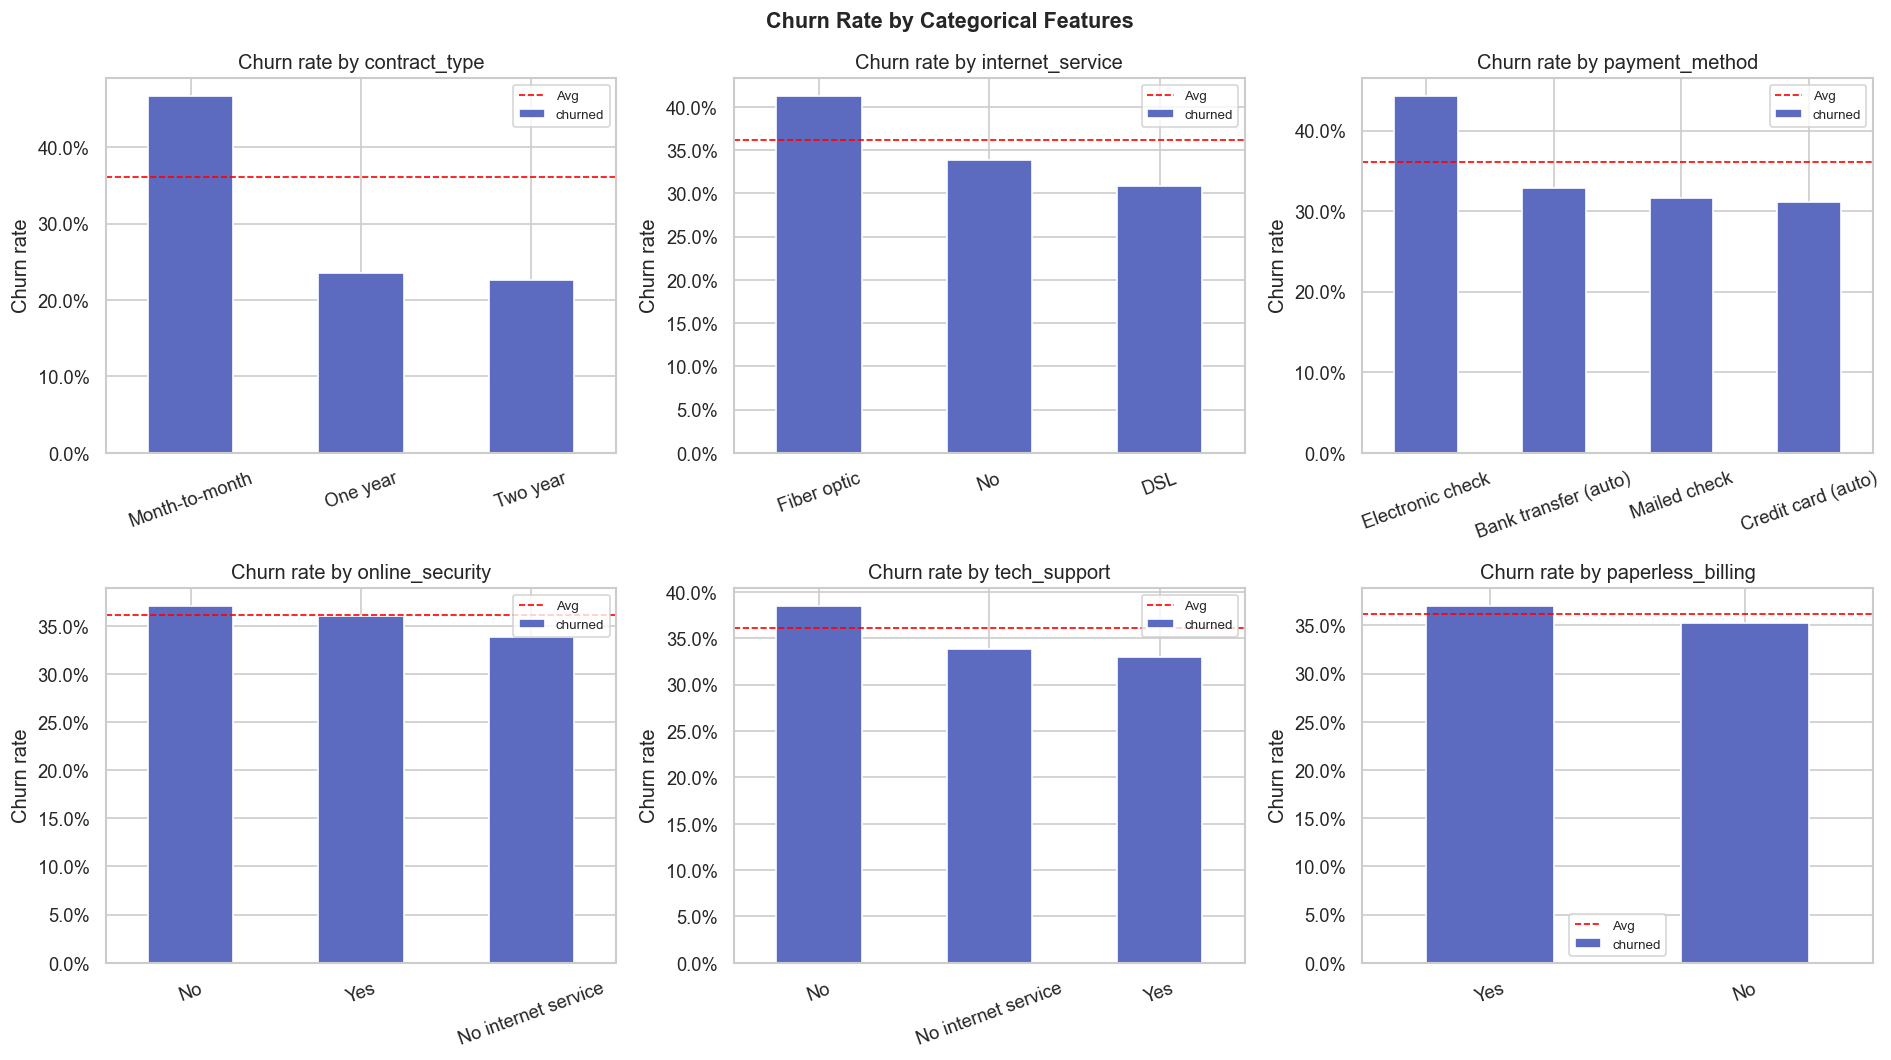

In [5]:
# Churn rate by each categorical feature
# The red dashed line = overall average churn rate
# Any bar well above the line = high-risk group worth targeting

#now time for the text based groups
cat_cols = ['contract_type', 'internet_service', 'payment_method',
            'online_security', 'tech_support', 'paperless_billing']

fig, axes = plt.subplots(2, 3, figsize=(16, 9)) # as 6 slots, so 2x3
axes = axes.flatten() # 2D to 1D
for i, col in enumerate(cat_cols): # keeps looping, i picks the subplot, and col picks the data
    churn_by_cat = df.groupby(col)['churned'].mean().sort_values(ascending=False) # groups all rows by category, calculates the churn rate via mean, sort by highest to lowest
    churn_by_cat.plot(kind='bar', ax=axes[i], color='#5C6BC0', edgecolor='white') # bar, correct subplot, color Indigo/purple, edgecolor white
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1)) # for this we imported mticker, will format the percentage
    axes[i].tick_params(axis='x', rotation=20) # category names are bigger, so will just rotate by 20
    # red line = baseline churn rate for visual comparison
    axes[i].axhline(churn_rate, color='red', linestyle='--', linewidth=1, label='Avg') # axhline is axes + horizontal + line, there is also axvline! This will be the mean line the average line!  
    axes[i].legend(fontsize=8)
plt.suptitle('Churn Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/categorical_churn_rates.png')
plt.show()

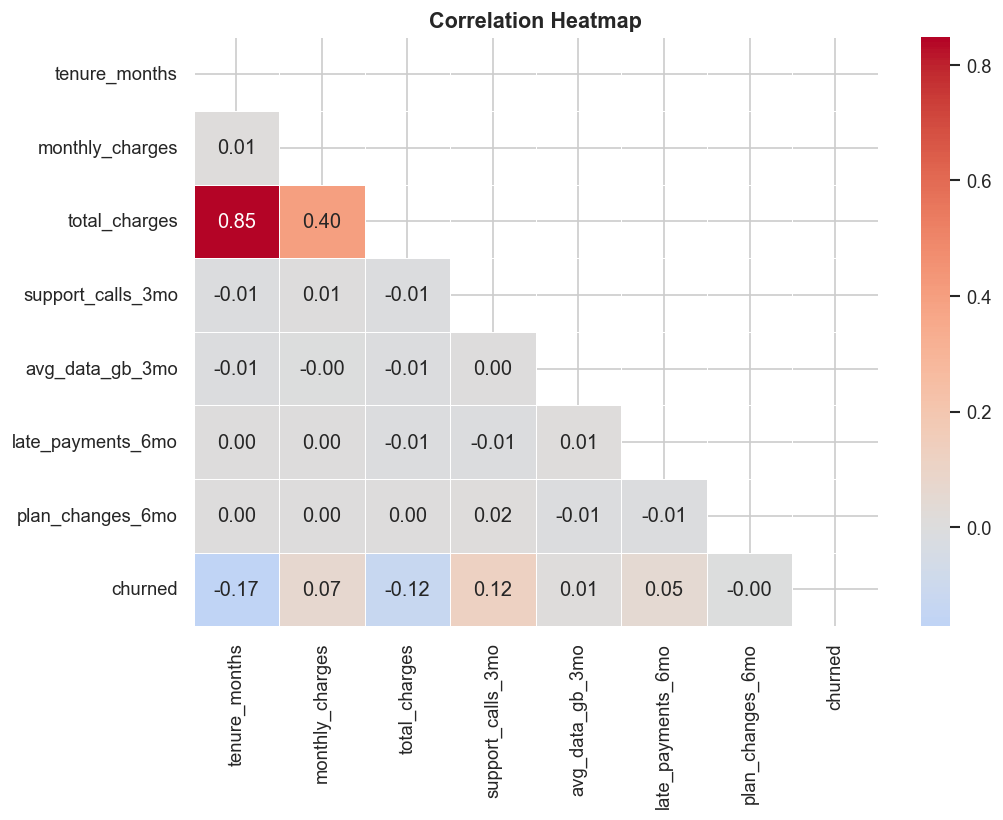

In [6]:
# Correlation heatmap — shows linear relationships between numeric features
# Helps spot multicollinearity (e.g. tenure_months and total_charges will be
# highly correlated — longer customers pay more over time)
# We use a lower triangle mask so the matrix isn't duplicated
fig, ax = plt.subplots(figsize=(9, 7)) # figure size determined
corr = df[num_cols + ['churned']].corr() # combines the 7 numeric columns list with the target columns(churned), .corr() correctaion btw every pair of columns and returns a grid!
mask = np.triu(np.ones_like(corr, dtype=bool))  # inner bracket creates a grid of True values, triu removes the top right from bottom left, True stays on top and False on bottom! for opposite could have done 'tril'
sns.heatmap(corr, # the matrix
            mask=mask, # lower triangle
            annot=True, # will show numbers
            fmt='.2f', # 2 decimal places
            cmap='coolwarm', # blue for strong negative (-1), White for no relation(0), Red for strong positive (+1)
            center=0, # colour midpoint
            linewidths=0.5, # grid lines
            ax=ax) #target axes
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png')
plt.show()

# if we see below the images, mostly its grey! Which means, most numeric features dont stronly predict the churn! Its the categorical features that determine it seems!

#### Churn is det by a combi of feature and here no single feature predict churn on its own! this si where XGBoost comes to rescue ehich captures these interactions

## 2. Preprocessing

In [ ]:
# importes from scikit-learn
from sklearn.model_selection import train_test_split # splitting data to training and testing
from sklearn.preprocessing import LabelEncoder # converts the text categories to numbers

# Drop customer_id just an identifier, not a predictive feature
df_model = df.drop(columns=['customer_id']).copy() # will drop the customer_id, and the copy is for the original df to stay untouched, in short the df_model will be a copy of df with the customer thing dropped

# Label-encode all categorical columns
# We use LabelEncoder (integer codes) rather than one-hot encoding, will label things, looks better
# because XGBoost handles ordinal integers natively and it keeps the feature space small
le = LabelEncoder()
cat_features = df_model.select_dtypes(include='object').columns.tolist() # will find all columns with text/categorical data, dtype=object, no numeric, .tolist() converts result into simple Python List

for col in cat_features:
    df_model[col] = le.fit_transform(df_model[col]) # loop throgh every categorical columns and converts text to integers

X = df_model.drop(columns=['churned'])  # features, therefore will drop the churned
y = df_model['churned']                 # target label, therefore the churned required

# 80/20 split — stratify=y ensures both splits have the same ~36% churn rate
# Without stratify, a random split could give a train set with 40% churn by chance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    # test size is 20%, train size is 80%
    #random_state locks randomness so you get the same split every time, we run the code, random state with any number will work well
    # statify=y, mirrors relaity 
    # in short the stratify=y keeps teh churn rate identical in both halves, random_state=42, makes the split reproducible in every run!
    # straify makes sures the churn is preserved in both the train and test splits, like otherwise some churn split will be in train and very few in test, no balance
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}')

Train: (5600, 19)  |  Test: (1400, 19)
Train churn rate: 36.2%  |  Test churn rate: 36.1%


## 3. Modeling

In [ ]:
# start simple first, if a simple model works well no complexity, if not use a complex model (XGBoost)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, #shows precsion, recall and F1 scores
                             confusion_matrix, #correct vs wrong pred
                              roc_auc_score, # single number rating model quality
                              RocCurveDisplay) #the ROC curve
from xgboost import XGBClassifier

# Baseline model: Logistic Regression
# Simple, fast, and interpretable — sets a performance floor
# If XGBoost barely beats this, complexity isn't justified

# 1000 iterations to find the best solution, random_state makes results reporducible, in short we are giving a fixed starting point everytime a code will be runned
lr = LogisticRegression(max_iter=1000, random_state=42) # LR is a scammer, having regression in name but does Classification step
lr.fit(X_train, y_train) # it looks at X_train (all features), it looks at y_train (each customer churned)! which feature matter the most for pred churn, fit(), model sits down and studys the training data
lr_pred = lr.predict(X_test) # hard prediction (0 or 1)
lr_proba = lr.predict_proba(X_test)[:, 1]  # probability of churn, grabs only the churn probability column, column index 1! there would be 2 classes class 0 (retained), class 1 (churned), will choose the class1

print('--- Logistic Regression (Baseline) ---')
# classification_report shows precision, recall and F1 per class
# We care most about recall for churners — missing a churner is expensive
print(classification_report(y_test, lr_pred, target_names=['Retained', 'Churned']))
# Precision is when you said churn, how often were we right?
# Recall, of all actual churners, how many did we catch
# F1 is the balance between the precision and recall

# lr_proba coz we will get a confidence level rather than the predicted values of 0 or 1
# also y_test as real answers from unseen dataset
# ROC-AUC measures how well the model ranks churners above non churners
print(f'ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}') #if a pick one random churner and one random retained customer, prob that the model correctly ranks the churner as mostly churner
# AUC=0.85 means the models correctly identifies the churner as higher risk that the retained customer by 85% of times

--- Logistic Regression (Baseline) ---
              precision    recall  f1-score   support

    Retained       0.69      0.84      0.76       894
     Churned       0.55      0.34      0.42       506

    accuracy                           0.66      1400
   macro avg       0.62      0.59      0.59      1400
weighted avg       0.64      0.66      0.64      1400

ROC-AUC: 0.6896


##### we are missings teh churners itself, cant risk that! We need to capture churners

In [9]:
# Main model: XGBoost
# Chosen over Random Forest for two reasons:
# 1. Faster training with gradient boosting
# 2. Native support for SHAP TreeExplainer — gives exact Shapley values
# Hyperparameters are conservative defaults — good for a 7k row dataset
xgb = XGBClassifier(
    n_estimators=300,        # number of trees
    max_depth=5,             # max tree depth, it controls overfitting
    learning_rate=0.05,      # small learning rate = more robust, 0.05 is best will learn slowly but steadily! more robust
    subsample=0.8,           # use 80% of rows per tree, reduces variance! better not 100% every tree sees slightly different data, every tree learn different patterns
    colsample_bytree=0.8,    # use 80% of features per tree, reduces variance! Same as above columns instead of rows! The dataset has 20 feature columns, we will just use 80% which is random 16 everytime
    use_label_encoder=False, # will get outputs clean
    eval_metric='logloss',   # XGBoost needs a way to measure how wrong it is after each tree, penalises confidently wrong predictions heavily!
    random_state=42,         # good at reproducibility
    n_jobs=-1                # use all CPU cores, 1 uses one cor, 2 used 2 cores, -1 uses all the available cores
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print('--- XGBoost (Main Model) ---')
print(classification_report(y_test, xgb_pred, target_names=['Retained', 'Churned']))
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}')

--- XGBoost (Main Model) ---
              precision    recall  f1-score   support

    Retained       0.72      0.84      0.78       894
     Churned       0.61      0.43      0.51       506

    accuracy                           0.69      1400
   macro avg       0.67      0.64      0.64      1400
weighted avg       0.68      0.69      0.68      1400

ROC-AUC: 0.7226


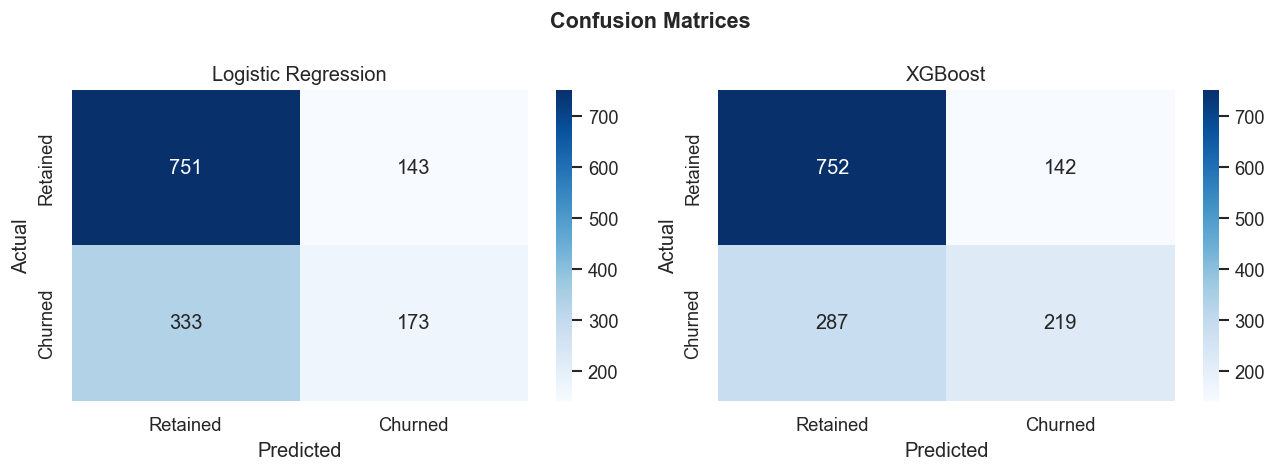

In [10]:
# Confusion matrix — shows where the model makes mistakes
# Top-left: correctly predicted retained (True Negatives)
# Bottom-right: correctly predicted churned (True Positives)
# Top-right: retained customers wrongly flagged as churners (False Positives = wasted offer spend)
# Bottom-left: churners we missed entirely (False Negatives = lost revenue)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, model, proba, name in [
    (axes[0], 
     lr, 
     lr_pred, 
     'Logistic Regression'), # title
    (axes[1], 
     xgb, 
     xgb_pred, 
     'XGBoost')
]:
    cm = confusion_matrix(y_test, proba) # y_test is the actual real answers, and proba is the model's predictions
    sns.heatmap(cm, 
                annot=True, # shows numbers inside box
                fmt='d', # formats as integers
                cmap='Blues', 
                ax=ax, #which subplot to draw
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout() 
plt.savefig('../outputs/figures/confusion_matrices.png')
plt.show()

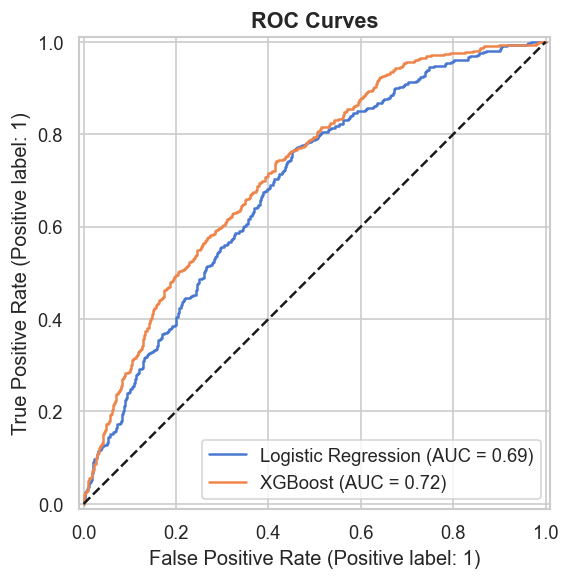

In [11]:
# ROC curve — shows the trade-off between catching churners (recall)
# and avoiding false alarms (precision) across all possible thresholds
# AUC closer to 1.0 = better; 0.5 = no better than random guessing
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, 
                                 lr_proba, 
                                 name='Logistic Regression', 
                                 ax=ax)
RocCurveDisplay.from_predictions(y_test, 
                                 xgb_proba, 
                                 name='XGBoost', 
                                 ax=ax)
ax.plot([0,1],[0,1],'k--', label='Random') # [x points], [y points], k=black and -- lines!
# (0,0) and (1,1) because axes goes from 0 to 1! cuts the sqaure exactly in half diagonally! model above the diagonal is better than random guessing and below diagonal is worse and on diagonal is random guessing
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves.png')
plt.show()

### Threshold is important, model will give a proba, but its our decsion who gets the retention offer
### 0.5 is default  ex if we get 400 customers, 300 churners and 100 false alarms! (100 are wasted offers)
### if 0.3, we flagged 700, 450 churners and 250 not! if we apply things according to formula, getting the threshold is better! 

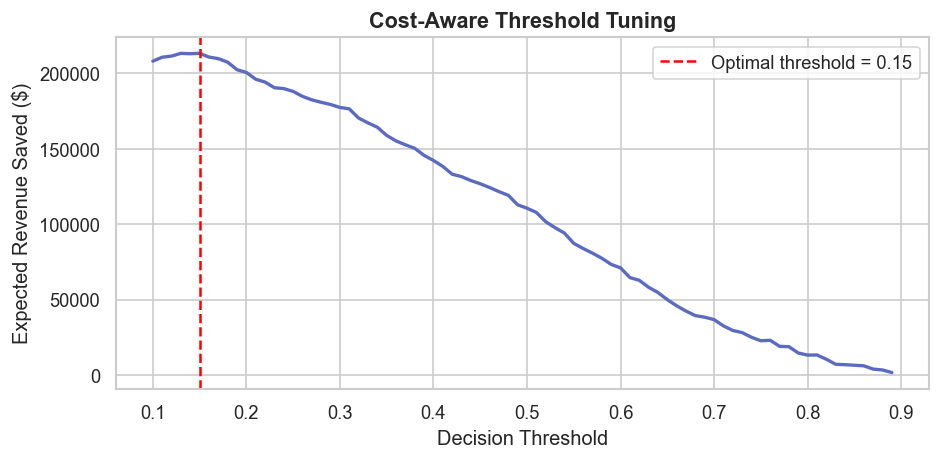

Optimal threshold: 0.15
Expected revenue saved at optimal threshold: $213,280


In [ ]:
# --- Stretch Goal: Cost-Aware Threshold Tuning ---
# By default, classifiers use 0.5 as the decision threshold
# But 0.5 isn't optimal from a business standpoint
# We want the threshold that maximises expected revenue saved
#
# Revenue saved at threshold t =
#   (true positives × LTV saved) - (all targeted customers × offer cost)
#
# USD figures grounded in the dataset:
#   Mean monthly charges = $69.84 (directly from the dataset)
#   Retention offer = ~1 month bill credit (standard US carrier practice)
#   LTV saved = $69.84/month × 24 months × 40% margin = ~$670

# 0.50 threshold is mathematcially conveninet but for business it is not optimal! 
OFFER_COST = 100   # USD — one month bill credit, standard US telecom retention offer (will inlcude the call cneter charges and all)
LTV_SAVED  = 670   # USD — profit saved by retaining a customer for ~2 years at 40% margin

thresholds = np.arange(0.1, 0.9, 0.01) # start, stop and increment
# 0.1 started because it flags customers with 10% churn probability! if it was zero would flag everyone, now will get 80 thresholds
revenues = []
for t in thresholds:
    preds = (xgb_proba >= t).astype(int) # first flagging the xgb_proba above t, astype converts the True/false to 1/0
    tp = ((preds == 1) & (y_test == 1)).sum()   # churners we correctly caught, use used and(&), we need both to be true
    fp = ((preds == 1) & (y_test == 0)).sum()   # non-churners we wrongly targeted
    # Revenue = saved from TP minus cost of offering to everyone we targeted
    revenue = tp * LTV_SAVED - (tp + fp) * OFFER_COST # every correct curner we save $670 and we spend, $100 for every offer we sent, no matter Chruner or not
    revenues.append(revenue) # we are not adding just appending like [45000, 56000]

best_threshold = thresholds[np.argmax(revenues)] # place where we will get the highest revenue we will mark that as the best threshold
best_revenue = max(revenues) # return the best revenue

# # we could also do this
# best_revenue = max(revenues)
# best_index = revenues.index(best_revenue)
# best_threshold = thresholds[best_index]

fig, ax = plt.subplots(figsize=(8, 4))
# threshold and revenue graph
ax.plot(thresholds, revenues, color='#5C6BC0', linewidth=2)
# redline to get the best threshold
ax.axvline(best_threshold, 
           color='red', 
           linestyle='--',
           label=f'Optimal threshold = {best_threshold:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Expected Revenue Saved ($)')
ax.set_title('Cost-Aware Threshold Tuning', fontsize=13, fontweight='bold')
ax.legend() # to show the legend box
plt.tight_layout()
plt.savefig('../outputs/figures/threshold_tuning.png')
plt.show()

print(f'Optimal threshold: {best_threshold:.2f}') # upto 2 decimal places as float
print(f'Expected revenue saved at optimal threshold: ${best_revenue:,.0f}') # , for better separation, .0 means no decimal points and f means formatted as float

In [13]:
# Save the trained model and feature names to disk
# These are loaded by the Streamlit app (app.py) so it can make live predictions
# without re-training every time the app starts
import pickle # python way of converting obj into a file and loading it back later

with open('../outputs/model.pkl', 'wb') as f: # wb is binary model f is the file inside the block
    # XGboost model dumping
    pickle.dump(xgb, f)
with open('../outputs/feature_names.pkl', 'wb') as f:
    # list of column names dumping, in exact order the model was trained
    pickle.dump(list(X.columns), f)
print('Model saved to outputs/model.pkl')

Model saved to outputs/model.pkl


## 4. SHAP Interpretability

#### SHapley Additive exPlanations
##### A way to explain why the model made a specific prediction, for each customer it tells which features pushed the churn proba up or down and by how much!

In [14]:
# SHAP explains how much each feture contributes to the specific prediction
import shap
shap.initjs()  # enables interactive JS visualisations in the Jupyter

# TreeExplainer is the fastest and most accurate SHAP method for tree-based models
# It computes exact Shapley values (not approximations) by exploiting the tree structure
explainer = shap.TreeExplainer(xgb) # used the tree structure to compute exact values not approximates
shap_values = explainer(X_test)  # compute SHAP values for every test sample

# Save for the Streamlit dashboard, so we don't recompute on every page load
with open('../outputs/shap_values.pkl', 'wb') as f:
    pickle.dump(shap_values, f)
print('SHAP values saved.')

SHAP values saved.


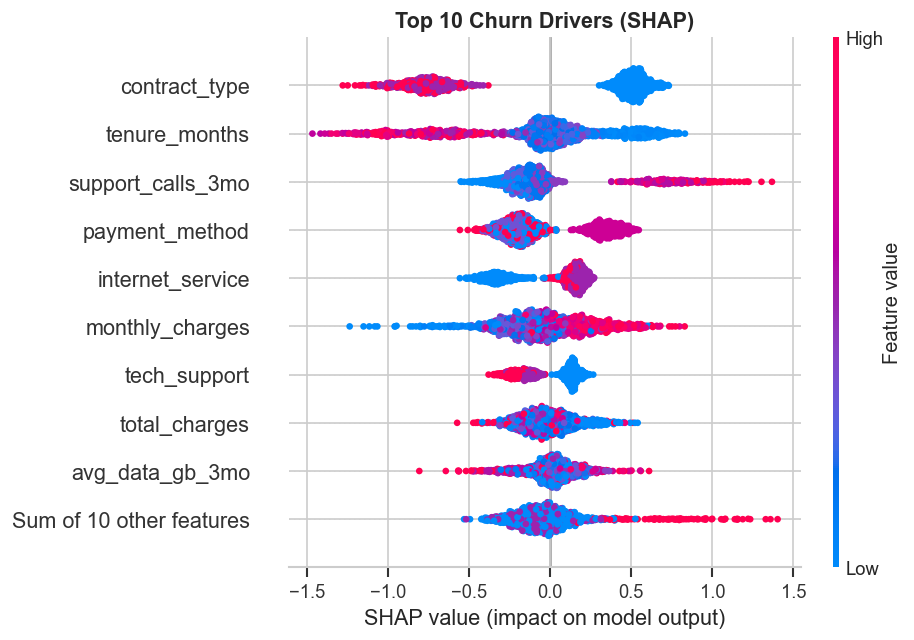

In [15]:
# Global SHAP: Beeswarm plot
# Shows the top 10 features that drive churn predictions across ALL customers
# Each dot = one customer
# Red dots = high feature value (supoort calls, high charges), Blue = low feature value (few calls, low charges)
# Dots to the right = pushed prediction toward churn and vice versa
# This is the most important chart for the CMO slide — it shows WHY customers churn
fig = plt.figure(figsize=(9, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title('Top 10 Churn Drivers (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_beeswarm.png', bbox_inches='tight')
plt.show()

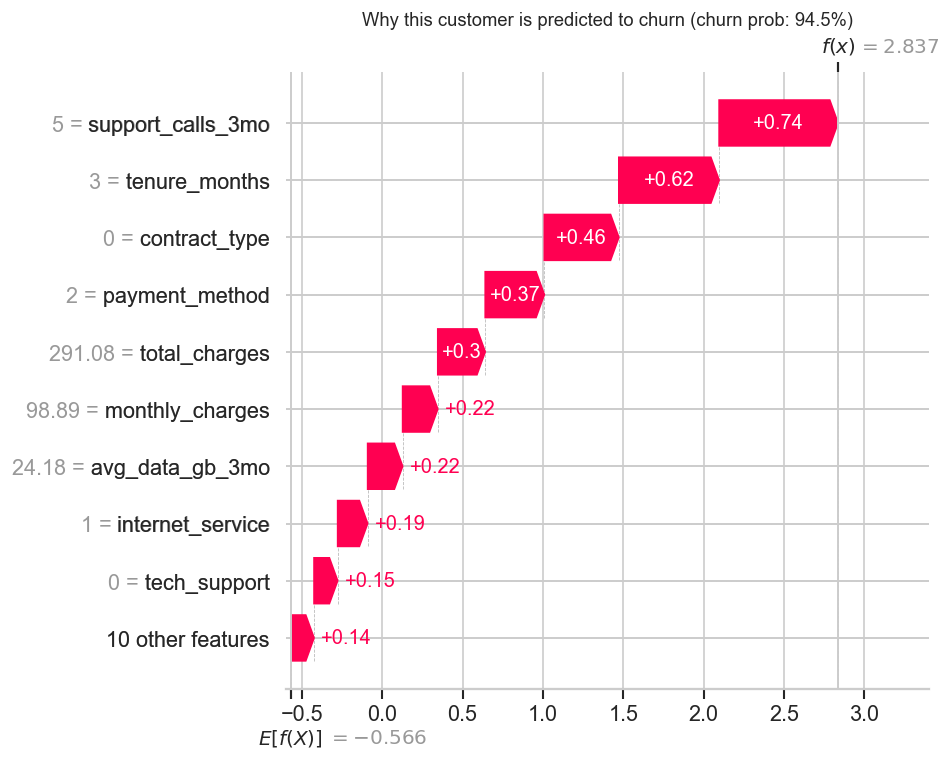

In [16]:
# Local SHAP: Waterfall for a high-risk churner, to understand why this specific person is going to churn
# Explains WHY the model predicts this specific customer will churn
# Red bars = features pushing toward churn, Blue = features pulling away from churn

high_risk_idx = np.argmax(xgb_proba)  # customer with highest predicted churn probability
fig = plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_values[high_risk_idx], show=False) # false, helps us to modify more better
plt.title(f'Why this customer is predicted to churn (churn prob: {xgb_proba[high_risk_idx]:.1%})', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall_churner.png', bbox_inches='tight')
plt.show()

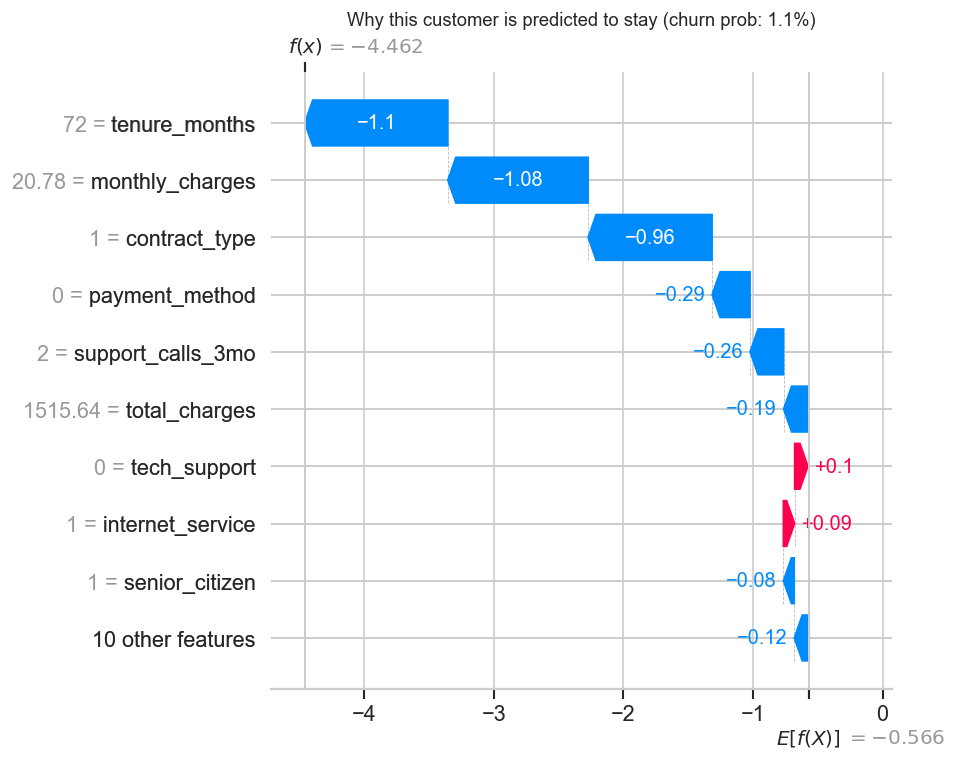

In [17]:
# Local SHAP: Waterfall for a low-risk retained customer
# Contrast with the churner above, shows what factors keep loyal customers
# Useful for understanding what good customer profiles look like
low_risk_idx = np.argmin(xgb_proba)  # customer with lowest predicted churn probability
fig = plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_values[low_risk_idx], show=False)
plt.title(f'Why this customer is predicted to stay (churn prob: {xgb_proba[low_risk_idx]:.1%})', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_waterfall_retained.png', bbox_inches='tight')
plt.show()

## 5. Churner Segmentation

Predicted churners: 5,505 (78.6% of customers)


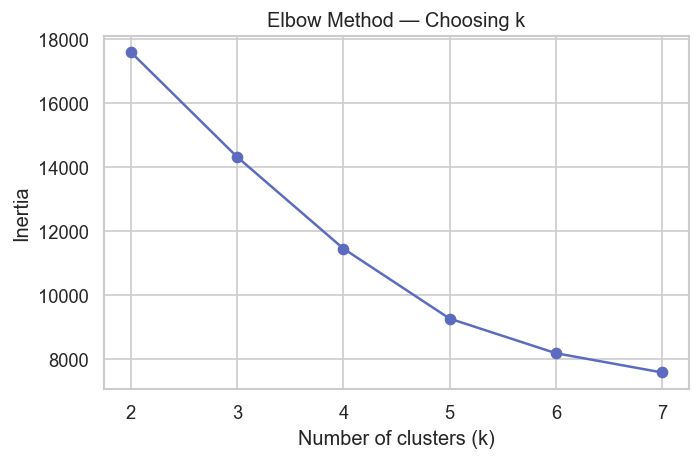

In [18]:
# in short, all churner are not same, will group them into clusters, therefore KMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler # rescales the numbers so all fetures are on the same playing field

# Get predicted churn probabilities for the FULL dataset (not just test set)
# We segment all predicted churners, not just those in the test split
full_proba = xgb.predict_proba(X)[:, 1] # 2 cloumns, not churn and churn (will chose the churn)
churner_mask = full_proba >= best_threshold  # use the cost-optimal threshold from earlier, will get True and False values
churner_df = df[churner_mask].copy() # will only store the values which is True
print(f'Predicted churners: {churner_mask.sum():,} ({churner_mask.mean():.1%} of customers)')

# Cluster using 4 actionable features — chosen because they directly map to business decisions (pricing, support, tenure-based onboarding)
cluster_features = ['monthly_charges', 
                    'support_calls_3mo', 
                    'tenure_months', 
                    'late_payments_6mo']

# StandardScaler: KMeans is distance-based so features must be on the same scale
# Without scaling, monthly_charges (range 20-120) would dominate tenure_months (range 1-72)
scaler = StandardScaler()
# fit learn the mean and spread the data, transform applies rescaling, fit_transform (both at once)
X_cluster = scaler.fit_transform(churner_df[cluster_features])

# Elbow method: find the k where adding more clusters stops reducing inertia meaningfully
# intertia is how speard the customers are within their cluster, closer the customers to their group's center, lower the inertia
# We expect k=3 based on the 3 business segments we hypothesised in the brief, Price Senstive, Service Frustrated, Early Leavers
inertias = [] # bucket to store result
K_range = range(2, 8) # will try 2 to 7
for k in K_range:
    km = KMeans(n_clusters=k, # try this many groups
                random_state=42, #fixed starting point
                n_init=10) # run Kmeans 10 times and keep the best
    km.fit(X_cluster) # actaully running the clustering
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(K_range, 
        inertias, 
        'o-', 
        color='#5C6BC0') #blue
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Choosing k', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/elbow_method.png')
plt.show()

In [19]:
# Final clustering with k=3 (confirmed by elbow method above)
km = KMeans(n_clusters=3, 
            random_state=42, 
            n_init=10)
churner_df['segment'] = km.fit_predict(X_cluster) # fit_predict learns and assigns every customer to a cluster

# Profile each cluster by computing mean values of the clustering features
# This tells us what each cluster 'looks like' so we can name it
# cluster_features already includes monthly_charges, no need to add it again
segment_profile = churner_df.groupby('segment')[cluster_features].mean().round(2) # splits into 3 groups, will look at 4 columns only, calculates the mean of each column, rounds to 2 decimal places
segment_profile['size'] = churner_df.groupby('segment').size() # counts how many customers in each group
segment_profile['pct'] = (segment_profile['size'] / len(churner_df) * 100).round(1) #perectange of each profiles
print(segment_profile)

         monthly_charges  support_calls_3mo  tenure_months  late_payments_6mo  \
segment                                                                         
0                  71.14               1.59          18.80               1.25   
1                  71.78               1.53          19.41               0.00   
2                  71.63               7.19          20.23               0.34   

         size   pct  
segment              
0        1678  30.5  
1        3163  57.5  
2         664  12.1  


In [20]:
# Assign human-readable labels based on which cluster has the strongest defining characteristic:
# - Highest support_calls_3mo → Service-Frustrated (clear outlier at 7.19 vs ~1.5 for others)
# - Highest late_payments_6mo → Payment-Delinquent (1.25 avg vs near-zero for others)
# - Remaining cluster → Contract-Free At-Risk (no late payments, no support issues, just on month-to-month)
segment_labels = {
    segment_profile['support_calls_3mo'].idxmax(): 'Service-Frustrated',
    segment_profile['late_payments_6mo'].idxmax(): 'Payment-Delinquent',
}
# The remaining cluster that doesn't match either characteristic above
remaining = set(range(3)) - set(segment_labels.keys())
for r in remaining:
    segment_labels[r] = 'Contract-Free At-Risk'

churner_df['segment_label'] = churner_df['segment'].map(segment_labels)
print('Segment label mapping:', segment_labels)
print(churner_df['segment_label'].value_counts())

Segment label mapping: {np.int32(2): 'Service-Frustrated', np.int32(0): 'Payment-Delinquent', 1: 'Contract-Free At-Risk'}
segment_label
Contract-Free At-Risk    3163
Payment-Delinquent       1678
Service-Frustrated        664
Name: count, dtype: int64


In [21]:
# Interactive scatter plot — x=monthly charges, y=support calls
# Bubble size = tenure (bigger = longer customer)
# Colour = segment label
# This goes into the Streamlit dashboard for judges to explore
fig = px.scatter(
    churner_df, # data to plot
    x='monthly_charges', 
    y='support_calls_3mo',
    color='segment_label', # different color per segment
    size='tenure_months', # how long they have been customer
    hover_data=['late_payments_6mo', 'contract_type'], # extra info that show when we will hover over the dot
    title='Churner Segments: Monthly Charges vs Support Calls',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.write_html('../outputs/figures/segments_scatter.html')  # saved as interactive HTML
fig.show()

In [22]:
# Save segment data for the Streamlit app
churner_df.to_csv('../outputs/churner_segments.csv', index=False) # saves the dataframe as CSV, False to not save the row numbers

# Clean summary table — used in the CMO deck
# .mean() only one calcuation, .agg() multiple calculations at once
summary = churner_df.groupby('segment_label').agg(
    size=('segment_label', 'count'),
    avg_monthly_charges=('monthly_charges', 'mean'),
    avg_support_calls=('support_calls_3mo', 'mean'),
    avg_tenure=('tenure_months', 'mean'),
    avg_late_payments=('late_payments_6mo', 'mean')
).round(2)
summary['pct_of_churners'] = (summary['size'] / len(churner_df) * 100).round(1)
print(summary)

                       size  avg_monthly_charges  avg_support_calls  \
segment_label                                                         
Contract-Free At-Risk  3163                71.78               1.53   
Payment-Delinquent     1678                71.14               1.59   
Service-Frustrated      664                71.63               7.19   

                       avg_tenure  avg_late_payments  pct_of_churners  
segment_label                                                          
Contract-Free At-Risk       19.41               0.00             57.5  
Payment-Delinquent          18.80               1.25             30.5  
Service-Frustrated          20.23               0.34             12.1  


## 6. Retention Recommendations

Three offers, one per segment. Each tied to the root cause the model and SHAP (SHapley Additive exPlanations) identified.

All three segments pay nearly the same monthly charges (~$71) and have been customers for roughly the same time (~19 months), so **price alone is not what separates them**. What actually separates them is behaviour: how often they call support and whether they pay on time.

---

### Segment A: Contract-Free At-Risk (57.5% of predicted churners, largest group)
**Profile:** Average $71.78/month, 1.53 support calls in the last 3 months, 19.4 months as a customer, zero late payments.  
**Root cause:** These customers are not angry and not struggling financially. They are simply on month-to-month contracts with nothing keeping them. Cancelling is easy with no penalty and no commitment.  
**Offer:** Proactively offer a 12-month plan with a 15% bill discount and a free add-on (streaming or security). Once they sign an annual contract, leaving becomes harder.  
**Expected impact:** If even 20% of this group upgrades to an annual contract, that is roughly 633 customers kept multiplied by $670 LTV (Lifetime Value, the total profit from keeping a customer for approximately 2 years) = **~$424K in recoverable revenue**.

---

### Segment B: Payment-Delinquent (30.5% of predicted churners)
**Profile:** Average $71.14/month, 1.59 support calls, 18.8 months as a customer, **1.25 late payments on average**.  
**Root cause:** Customers who keep missing payments are quietly disengaging from the service before they formally cancel. The billing friction is wearing them down.  
**Offer:** Proactive billing outreach. Offer a flexible payment date change (so it aligns with their payday), waive one late fee, and enrol them in auto-pay with a $10/month discount as a reward.  
**Expected impact:** Fixing the payment friction before it turns into a cancellation. Auto-pay enrolment also means fewer late payments in future, reducing the risk of this repeating.

---

### Segment C: Service-Frustrated (12.1% of predicted churners, smallest but highest risk per customer)
**Profile:** Average $71.63/month, **7.19 support calls** in the last 3 months (compared to roughly 1.5 for all other segments), 20.2 months as a customer, 0.34 late payments.  
**Root cause:** These customers have called support 7 or more times in 3 months and their problem still has not been fixed. They are not leaving because of price. They are leaving because the service is broken for them and nobody has resolved it.  
**Offer:** Assign a dedicated support representative with a 48-hour SLA (Service Level Agreement, a formal promise to resolve the issue within 48 hours). If not resolved in time, give one month free. Escalate immediately to a senior technician on next contact.  
**Expected impact:** Fixing the actual service problem before the frustration turns into a cancellation. This segment is small (664 customers) but the fix is the clearest of all three. Solve the service issue and the customer has no reason to leave.

## 7. Limitations & Risks

1. **Correlation is not causation.** Just because customers who call support a lot tend to churn more does not mean calling support *causes* churn. The real cause might be a bad network. The model spots the warning sign, not what is actually causing the problem.

2. **Price does not separate the segments.** All three churner groups pay nearly the same (~$71/month). The model cannot tell us who is price-sensitive and who is not. Only support calls and late payments meaningfully separate them. Do not build pricing-tier offers based on this model.

3. **Stationarity assumption (the model assumes the future looks like the past).** If a competitor launches a big promotion, prices change, or there is a network outage, customer behaviour will shift and the model's predictions will go out of date. Retrain every quarter.

4. **The data is synthetic (artificially generated, not real customers).** Real customer patterns may look different. Before acting on the revenue projections, test the model on a sample of actual customers first.

5. **Deadweight cost (wasted offer spend).** Some customers who were never going to leave will still receive and accept the retention offer. These are false positives (FP, meaning customers the model incorrectly flagged as churners). This wasted spend is already factored into the revenue calculation, but it grows as the threshold is lowered. Keep a close eye on how many non-churners are redeeming offers in the first campaign wave.

6. **Retention offer elasticity (not everyone can be saved).** The model predicts *who will churn*, not *who will change their mind if we send an offer*. Some customers have already decided to leave and no offer will stop them. Uplift modelling (a separate model that predicts who will actually respond to the offer) is the proper solution and is recommended as a next step.

7. **Feature drift (the data patterns can shift over time).** If the business changes its pricing, contracts, or support processes, the features the model was trained on will start to look different and accuracy will silently drop. Set up a monthly AUC (Area Under the Curve, a measure of model quality) monitoring check to catch this early.

## 8. 60-Day Success Metrics

**Primary metric (the main number we track):** Monthly churn rate in the group that received the offer vs. a control group that received nothing.
- Baseline (current rate): 2.3% monthly churn (stated in the brief).
- Target: Churn rate in the treated group drops to 1.8% or below by Day 60 (matching the industry benchmark).

**How to measure:**
- A/B test (a controlled experiment): randomly split all predicted churners into two equal groups.
  - 50% receive the retention offer. This is the **treatment group**.
  - 50% receive nothing. This is the **control group**.
- Compare churn rates between both groups at Day 30 and Day 60.
- Use a two-proportion z-test (a statistical check that confirms the difference between groups is real and not just random luck) to validate the result.

**Per-segment targets (what success looks like for each group):**

| Segment | Size | Offer | Success Signal |
|---|---|---|---|
| Contract-Free At-Risk | 3,163 | Contract upgrade + 15% discount | % who switched to an annual plan by Day 30 |
| Payment-Delinquent | 1,678 | Flexible payment date + fee waiver | Late payment rate drops and auto-pay enrolment rises |
| Service-Frustrated | 664 | Dedicated rep + 48h SLA (Service Level Agreement) | Issue resolved and churn rate falls in this group |

**Secondary metrics (supporting signals, not the main measure of success):**
- **Offer redemption rate:** what percentage of customers actually accepted the offer. Helps estimate the real cost per campaign for next time.
- **NPS (Net Promoter Score) delta:** did customer satisfaction improve in the treated group vs. the control group by Day 60? NPS measures how likely customers are to recommend the service to a friend on a scale of 0 to 10.
- **ARPU (Average Revenue Per User) change:** did retained customers keep paying the same amount, or did the discount reduce their bill so much that the company is not actually better off? This checks whether customers were truly retained or whether their churn was simply delayed by one billing cycle.

**What NOT to use as the primary success metric:**
Offer click rate or redemption rate alone. A customer who clicks a discount link and still cancels at Day 61 is not a win. A customer who stays is the only win that counts.